In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features. The observations are as follow:
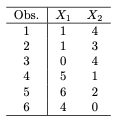

### (a) 
Plot the observations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


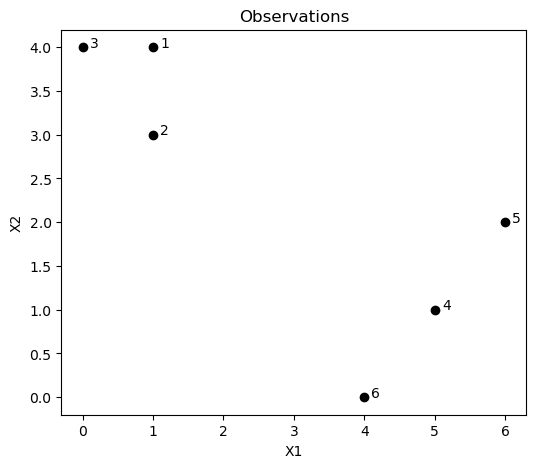

In [2]:
data = np.array([
    [1, 4],
    [1, 3],
    [0, 4],
    [5, 1],
    [6, 2],
    [4, 0]
])

obs = np.arange(1, 7)

# Plot observations
plt.figure(figsize=(6,5))
plt.scatter(data[:,0], data[:,1], c='black')
for i, txt in enumerate(obs):
    plt.text(data[i,0]+0.1, data[i,1], str(txt))
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Observations")
plt.show()

### (b) 
Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [3]:
np.random.seed(1)
labels = np.random.choice([0,1], size=6)
print("Initial cluster labels:", labels)

def compute_centroids(data, labels, K):
    centroids = np.zeros((K, data.shape[1]))
    for k in range(K):
        centroids[k] = data[labels == k].mean(axis=0)
    return centroids

def assign_clusters(data, centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

Initial cluster labels: [1 1 0 0 1 1]


### (c) 
Compute the centroid for each cluster.

In [4]:
# (c) Compute centroids for current labels
def compute_centroids(data, labels, K):
    centroids = np.zeros((K, data.shape[1]))
    for k in range(K):
        centroids[k] = data[labels == k].mean(axis=0)
    return centroids

K = 2
centroids = compute_centroids(data, labels, K)
print("Centroids after initial random assignment:\n", centroids)


Centroids after initial random assignment:
 [[2.5  2.5 ]
 [3.   2.25]]


### (d) 
Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [5]:
# (d) Assign each observation to nearest centroid (Euclidean distance)
def assign_clusters(data, centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

new_labels = assign_clusters(data, centroids)
print("New cluster labels after re-assignment:", new_labels)


New cluster labels after re-assignment: [0 0 0 1 1 1]


### (e) 
Repeat (c) and (d) until the answers obtained stop changing.

In [6]:
# (e) Iterate until cluster assignments stop changing
for iteration in range(10):
    centroids = compute_centroids(data, labels, K)
    new_labels = assign_clusters(data, centroids)
    print(f"Iteration {iteration+1}: labels = {new_labels}")
    if np.all(labels == new_labels):
        print(f"Converged after {iteration+1} iterations.")
        break
    labels = new_labels

print("Final centroids:\n", centroids)
print("Final cluster labels:", labels)


Iteration 1: labels = [0 0 0 1 1 1]
Iteration 2: labels = [0 0 0 1 1 1]
Converged after 2 iterations.
Final centroids:
 [[0.66666667 3.66666667]
 [5.         1.        ]]
Final cluster labels: [0 0 0 1 1 1]


### (f)
In your plot from (a), color the observations according to the cluster labels obtained.

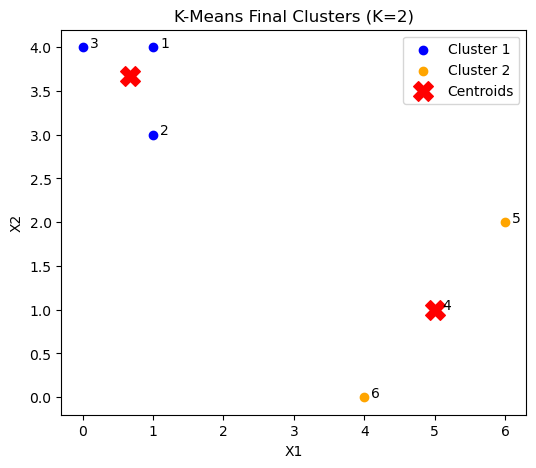

In [7]:
plt.figure(figsize=(6,5))
colors = np.array(['blue', 'orange'])
for k in range(K):
    plt.scatter(data[labels==k,0], data[labels==k,1], c=colors[k], label=f"Cluster {k+1}")
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200, label='Centroids')
for i, txt in enumerate(obs):
    plt.text(data[i,0]+0.1, data[i,1], str(txt))
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("K-Means Final Clusters (K=2)")
plt.show()